In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import joblib


In [66]:
file_path = r"C:\Users\Rohit Dhiman\Downloads\Salary_Data.csv"
df = pd.read_csv(file_path)
df.head()


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [67]:
df.columns


Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [68]:
print("\n---- Basic info ----")
print(df.info())
print("\n---- Numerical description ----")
print(df.describe(include=[np.number]).T)
print("\n---- Categorical value counts ----")
for col in ['Gender', 'Education Level', 'Job Title']:
    print(f"\n{col} value counts:\n", df[col].value_counts().head(20))


---- Basic info ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB
None

---- Numerical description ----
                      count           mean           std    min      25%  \
Age                  6702.0      33.620859      7.614633   21.0     28.0   
Years of Experience  6701.0       8.094687      6.059003    0.0      3.0   
Salary               6699.0  115326.964771  52786.183911  350.0  70000.0   

                          50%       75%       max  
Age                    

In [69]:
df = df.copy()
# If Salary missing -> drop (can't train)
df = df.dropna(subset=['Salary'])
# For other columns, simple filling
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Years of Experience'] = df['Years of Experience'].fillna(df['Years of Experience'].median())
df['Gender'] = df['Gender'].fillna('Unknown')
df['Education Level'] = df['Education Level'].fillna('Unknown')
df['Job Title'] = df['Job Title'].fillna('Unknown')


In [70]:
def clean_salary(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, str):
        # remove commas, currency symbols
        x = x.replace(',', '').replace('$', '').replace('₹', '').strip()
    try:
        return float(x)
    except:
        return np.nan

df['Salary'] = df['Salary'].apply(clean_salary)
df = df.dropna(subset=['Salary'])

In [82]:
le_gender = LabelEncoder()
df['Gender_enc'] = le_gender.fit_transform(df['Gender'].astype(str))

le_edu = LabelEncoder()
df['Edu_enc'] = le_edu.fit_transform(df['Education Level'].astype(str))

# d) Encode Job Title as two representations:
#    1) A LabelEncoder numeric version for model features (simple)
#    2) TF-IDF vectorizer for recommendation similarity
le_job = LabelEncoder()
df['Job_enc'] = le_job.fit_transform(df['Job Title'].astype(str))

# Prepare TF-IDF on Job Title for recommender
tfidf = TfidfVectorizer(min_df=1, stop_words='english', ngram_range=(1,2))
tfidf_matrix = tfidf.fit_transform(df['Job Title'].astype(str))

In [72]:
feature_cols = ['Age', 'Years of Experience', 'Gender_enc', 'Edu_enc', 'Job_enc']
X = df[feature_cols].copy()
y = df['Salary'].copy()

# Scale numeric columns (Age, Years of Experience)
scaler = StandardScaler()
X[['Age', 'Years of Experience']] = scaler.fit_transform(X[['Age', 'Years of Experience']])

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [74]:
rf = RandomForestRegressor(n_estimators=250, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=250, n_jobs=-1, random_state=42)


Model Evaluation:
RMSE: 8,127.93
R^2 : 0.9768


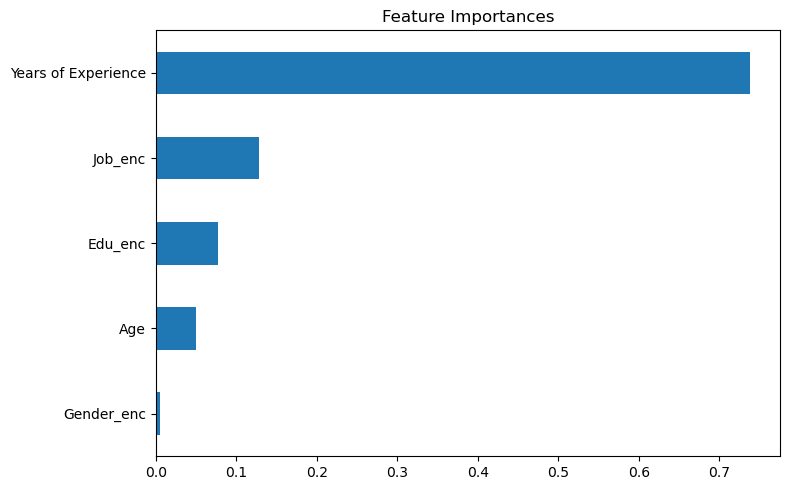

In [75]:
y_pred = rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print(f"RMSE: {rmse:,.2f}")
print(f"R^2 : {r2:.4f}")

# Feature importance plot
importances = rf.feature_importances_
fi = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(8,5))
fi.plot(kind='barh')
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

In [83]:
joblib.dump(rf, "salary_rf_model.joblib")
joblib.dump(scaler, "salary_scaler.joblib")
joblib.dump(le_gender, "le_gender.joblib")
joblib.dump(le_edu, "le_edu.joblib")
joblib.dump(le_job, "le_job.joblib")
joblib.dump(tfidf, "jobtitle_tfidf.joblib")
joblib.dump(tfidf_matrix, "tfidf_matrix.joblib")

print("\nSaved model and encoders to disk.")


Saved model and encoders to disk.


In [77]:
def predict_salary(profile: dict):
    """
    profile should be a dict with keys:
    - 'Age' (int/float)
    - 'Gender' (string)
    - 'Education Level' (string)
    - 'Job Title' (string)
    - 'Years of Experience' (int/float)
    """
    # Build dataframe with same features
    p = {}
    p['Age'] = profile.get('Age', np.nan)
    p['Years of Experience'] = profile.get('Years of Experience', np.nan)
    gender = str(profile.get('Gender', 'Unknown'))
    edu = str(profile.get('Education Level', 'Unknown'))
    job_title = str(profile.get('Job Title', 'Unknown'))

    # encode
    try:
        p['Gender_enc'] = le_gender.transform([gender])[0]
    except:
        # unseen label -> add as most common (or fallback 0)
        p['Gender_enc'] = 0

    try:
        p['Edu_enc'] = le_edu.transform([edu])[0]
    except:
        p['Edu_enc'] = 0

    try:
        p['Job_enc'] = le_job.transform([job_title])[0]
    except:
        # fallback: if job not seen, assign a generic code (e.g., mode)
        p['Job_enc'] = int(df['Job_enc'].mode()[0])

    p_df = pd.DataFrame([p], columns=feature_cols)
    # scale numeric
    p_df[['Age', 'Years of Experience']] = scaler.transform(p_df[['Age', 'Years of Experience']])
    # predict
    pred_salary = rf.predict(p_df)[0]
    return float(pred_salary)

In [78]:
def recommend_jobs_by_title(profile: dict, top_k=5, experience_weight=0.4):
    """
    Return top_k job rows from df that match the profile job title and experience.
    Uses TF-IDF cosine similarity on Job Title and penalizes for experience difference.

    profile keys: 'Job Title', 'Years of Experience'
    """
    job_title = str(profile.get('Job Title', ''))
    years = float(profile.get('Years of Experience', 0))

    # Compute TF-IDF vector for the query title
    q_vec = tfidf.transform([job_title])  # shape (1, n_features)
    sim = cosine_similarity(q_vec, tfidf_matrix).flatten()  # similarity to all dataset rows

    # Experience closeness score (higher is better). We'll make normalized closeness in [0,1]
    # smaller absolute diff -> closer to 1
    exp_diff = np.abs(df['Years of Experience'].fillna(0).astype(float) - years)
    # convert to score: score = 1 / (1 + diff)
    exp_score = 1 / (1 + exp_diff)

    # Combine scores
    combined_score = (1 - experience_weight) * sim + experience_weight * exp_score

    # Attach to df copy and sort
    df_recs = df.copy()
    df_recs['match_score'] = combined_score
    df_recs = df_recs.sort_values('match_score', ascending=False)

    # Return top_k columns useful for display
    display_cols = ['Job Title', 'Years of Experience', 'Education Level', 'Gender', 'Salary', 'match_score']
    return df_recs[display_cols].head(top_k)

In [84]:
example_profile = {
    'Age': 27,
    'Gender': 'Male',
    'Education Level': 'Bachelor',
    'Job Title': 'Data Scientist',
    'Years of Experience': 2
}

predicted = predict_salary(example_profile)
print(f"\nPredicted salary for example profile: {predicted:,.2f}")

print("\nTop recommended jobs (by title similarity + experience):")
print(recommend_jobs_by_title(example_profile, top_k=5))


Predicted salary for example profile: 87,394.04

Top recommended jobs (by title similarity + experience):
          Job Title  Years of Experience Education Level Gender    Salary  \
503  Data Scientist                  2.0             PhD   Male  115000.0   
406  Data Scientist                  2.0             PhD   Male  115000.0   
444  Data Scientist                  2.0             PhD   Male  115000.0   
471  Data Scientist                  2.0             PhD   Male  115000.0   
479  Data Scientist                  2.0             PhD   Male  115000.0   

     match_score  
503          1.0  
406          1.0  
444          1.0  
471          1.0  
479          1.0  


In [85]:
recommendations = recommend_jobs_by_title(example_profile, top_k=20)
recommendations.to_csv("demo_recommendations.csv", index=False)
print("\nSaved demo_recommendations.csv")


Saved demo_recommendations.csv
